# BNB: Region Sketch and Cells Extraction
Data is obtained from 10X Genomics

In [1]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

env: ANYWIDGET_HMR=1


In [2]:
import celldega as dega
from celldega.pre.boundary_tile import batch_transform_geometries
from celldega.pre import to_geometry
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import copy
import os
import json
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import geopandas as gpd
from shapely.geometry import shape, Point, Polygon
dega.__version__

'0.8.1'

# Local Hosted Example

In [12]:
from http.server import HTTPServer, SimpleHTTPRequestHandler
import threading as thr

class CORSHTTPRequestHandler(SimpleHTTPRequestHandler):
    def end_headers(self):
        self.send_header('Access-Control-Allow-Origin', '*')
        self.send_header('Access-Control-Allow-Methods', 'GET, OPTIONS')
        self.send_header('Access-Control-Allow-Headers', 'X-Requested-With, content-type, Authorization')  # Added Authorization
        self.send_header('Access-Control-Allow-Credentials', 'true')
        super().end_headers()

    def do_OPTIONS(self):
        self.send_response(200)
        self.end_headers()

    def log_message(self, format, *args):
        # Override log_message to prevent logging to the console.
        pass


server = HTTPServer(("", 0), CORSHTTPRequestHandler)
print(f"Server running on port {server.server_address[1]}")

service = thr.Thread(target=server.serve_forever)
service.start()

server_address = server.server_address[1]

dataset_name = 'Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs'
# dataset_name = 'Xenium_V1_human_Pancreas_FFPE_outs' # smaller dataset
sample = dataset_name
region = 0
tech = 'Xenium'
print (tech)

DATA_DIR = f'/Users/whuan/dev/celldega/data'
data_dir = f'{DATA_DIR}/{dataset_name}'
path_landscape_files = f'{dataset_name}'

# Optional
initial_region_json_file = f""

if os.path.exists(initial_region_json_file):
    with open(initial_region_json_file, 'r') as file:
        initial_region = json.load(file)
else:
    initial_region = {}


if tech.lower() == 'xenium':
    base_url = f"http://localhost:{server_address}/{dataset_name}/"
elif tech.lower() == 'merscope':
    base_url = f"http://localhost:{server_address}/{dataset_name}/region_{region}"
    
print (base_url)


Server running on port 51519
Xenium
http://localhost:51519/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs/


In [13]:
landscape_ist = dega.Landscape(
    technology=tech,
    base_url = base_url,
    region={}, # It is an empty {} in this case.
    nbhd={},
)

landscape_ist


# ovarian_cancer_markers = [
#     "MUC16",
#     "TP53",
#     "BRCA1",
#     "BRCA2",
#     "KRAS",
#     "PTEN",
#     "PIK3CA",
#     "FOXL2",
#     "HNF1B",
#     "MSH2",
#     "MSH6",
#     "MLH1",
#     "PMS2",
#     "CCNE1",
# ]



Landscape(base_url='http://localhost:51519/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs/', technology='Xenium')

## Github Hosted Example


In [41]:
# base_url = 'https://raw.githubusercontent.com/broadinstitute/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs/main/'

# landscape_ist = dega.Landscape(
#     technology='Xenium',
#     base_url = base_url,
#     nbhd={},
# )

# landscape_ist


## Draw regions of interest.
1. To draw a region, click "RGN" above and then click "SKTCH".
2. When "SKTCH" is activated (blue), you can start to draw a polygon in the visualization window.
3. Single-click to add vertices and click the starting point to close the polygon. The "SKTCH" sign will will grey out once the polygon is finished.
4. To draw another polygon, click "SKTCH" and repeat 2,3.

## Save regions

In [5]:
initial_region = copy.deepcopy(landscape_ist.region)

# Specify the output file path
output_file = f"{path_landscape_files}/initial_regions.json"

# Save the data to a JSON file
with open(output_file, "w") as file:
    json.dump(initial_region, file, indent=4)

print(f"Data has been saved to {output_file}")

Data has been saved to Xenium_V1_human_Pancreas_FFPE_outs/initial_regions.json


## Next time, you can load pre-selected region and click "RGN" to view it

In [14]:
initial_region_json_file = f"{path_landscape_files}/initial_regions.json"
with open(initial_region_json_file, 'r') as file:
    initial_region = json.load(file)

landscape_ist = dega.Landscape(
    technology=tech,
    base_url = base_url,
    region=initial_region,
    nbhd={},
)

landscape_ist

Landscape(base_url='http://localhost:51519/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs/', region={'type': 'Fea…

## Convert the region(s) geometry to GeoDataFrame

In [15]:
# Convert FeatureCollection into a GeoDataFrame
features = landscape_ist.region["features"]
geometries = [shape(feature["geometry"]) for feature in features]
properties = [feature["properties"] for feature in features]
gdf_pixel = gpd.GeoDataFrame(properties, geometry=geometries)
gdf_pixel = gdf_pixel.rename(columns = {'name':'roi'})
gdf_pixel['roi'] = gdf_pixel['roi'].apply(lambda x: x.replace('Feature','ROI'))
gdf_pixel.head()

,area,roi,color,geometry
0,8.524067e+07,ROI 1,"[50.38252999404976, 171.42419118220474, 2.4771...","POLYGON ((12399.825 14504.681, 14069.862 13098..."
1,3.066227e+07,ROI 2,"[79.98959877143285, 128.68419351357974, 162.15...","POLYGON ((41232.827 19225.682, 42077.577 19066..."
2,5.847033e+08,ROI 3,"[110.46152566756015, 2.5032325793740675, 66.94...","POLYGON ((29354.682 476.855, 36945.621 377.290..."


## Use transform matrix (inversed) to convert pixel space to micron space

In [16]:
path_transformation_matrix = f'{path_landscape_files}/xenium_transform.csv'

transformation_matrix = pd.read_csv(
    path_transformation_matrix, header=None, sep=" "
).values

# From pixel to micron space
inverse_matrix = np.linalg.inv(transformation_matrix)

gdf_micron = gdf_pixel.copy()
gdf_micron["geometry"] = batch_transform_geometries(gdf_micron["geometry"], inverse_matrix, 1)
gdf_micron['geometry'] = gdf_micron['geometry'].apply(to_geometry)
gdf_micron['area'] = gdf_micron.geometry.area
gdf_micron

,area,roi,color,geometry
0,3.849150e+06,ROI 1,"[50.38252999404976, 171.42419118220474, 2.4771...","POLYGON ((2634.963 3082.245, 2989.846 2783.429..."
1,1.384593e+06,ROI 2,"[79.98959877143285, 128.68419351357974, 162.15...","POLYGON ((8761.976 4085.458, 8941.486 4051.726..."
2,2.640301e+07,ROI 3,"[110.46152566756015, 2.5032325793740675, 66.94...","POLYGON ((6237.870 101.332, 7850.945 80.174, 7..."


## Save gdf and gdf_micron to geo parquet


In [17]:
fname_region_gdf = f'{path_landscape_files}/sketched_regions.parquet'

gdf_pixel.to_parquet(f'{path_landscape_files}/sketched_regions_pixel.parquet', index=False)
gdf_micron.to_parquet(f'{path_landscape_files}/sketched_regions_micron.parquet', index=False)

# Load Geo parquet
gdf_micron = gpd.read_parquet(f'{path_landscape_files}/sketched_regions_micron.parquet')
display(gdf_micron)


,area,roi,color,geometry
0,3.849150e+06,ROI 1,"[50.38252999404976, 171.42419118220474, 2.4771...","POLYGON ((2634.963 3082.245, 2989.846 2783.429..."
1,1.384593e+06,ROI 2,"[79.98959877143285, 128.68419351357974, 162.15...","POLYGON ((8761.976 4085.458, 8941.486 4051.726..."
2,2.640301e+07,ROI 3,"[110.46152566756015, 2.5032325793740675, 66.94...","POLYGON ((6237.870 101.332, 7850.945 80.174, 7..."


## Load a micron space data to validate

In [18]:
path_meta_cell_micron = f'{data_dir}/cells.csv.gz'
meta_cell = pd.read_csv(path_meta_cell_micron)
# Create geometry column using x_centroid and y_centroid
geometry = [Point(xy) for xy in zip(meta_cell["x_centroid"], meta_cell["y_centroid"])]
# Convert to GeoDataFrame
meta_cell_gdf = gpd.GeoDataFrame(meta_cell, geometry=geometry)
meta_cell_gdf.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,nucleus_count,segmentation_method,geometry
0,aaaaebmm-1,540.864624,4230.247070,303,0,0,0,0,31,334,44.659533,31.835157,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,POINT (540.865 4230.247)
1,aaaafhpp-1,532.860718,4242.919922,311,0,0,0,0,28,339,57.664533,38.247345,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,POINT (532.861 4242.920)
2,aaaahcem-1,527.639893,4240.649414,301,0,0,0,0,32,333,39.827814,27.590470,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,POINT (527.640 4240.649)
3,aaaakeoi-1,534.369263,4234.182617,369,0,0,0,0,58,427,60.870627,38.879533,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,POINT (534.369 4234.183)
4,aaaalald-1,527.593750,4232.856934,295,0,0,0,0,47,342,50.484689,46.510939,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,POINT (527.594 4232.857)


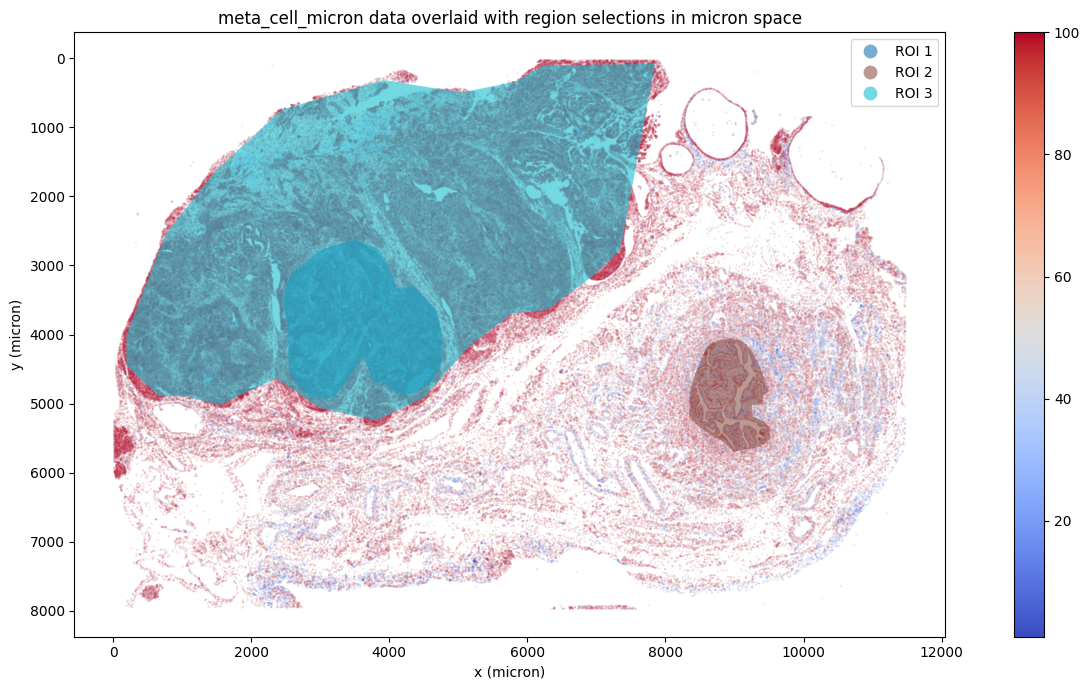

In [19]:
fig, ax = plt.subplots(figsize=(14,7))
meta_cell_gdf.plot(
    ax=ax, column='total_counts',
    aspect=1, legend=True,
    vmin=1, vmax=100, s=0.1,
    alpha=0.2, cmap='coolwarm')
gdf_micron.plot(ax=ax, column='roi', legend=True, cmap='tab10', alpha=0.6)
ax.invert_yaxis()
plt.title('meta_cell_micron data overlaid with region selections in micron space')
plt.xlabel('x (micron)')
plt.ylabel('y (micron)')
plt.tight_layout()
plt.show()